# 05 — Compare Traditional Classifier vs CNN
Both methods classify the 5 signal types. We evaluate them on the **same held-out
test set** (saved by notebook 04) and plot accuracy against noise level (SNR).

In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

DATA_PATH = '../data/RadChar-Small.h5'
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# load data
with h5py.File(DATA_PATH, 'r') as f:
    iq     = f['iq'][:]
    labels = f['labels'][:]

y   = labels['signal_type'].astype(np.int64)
snr = labels['signal_to_noise_ratio']

In [3]:
# rebuild and reload the trained CNN from notebook 04
class RadarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2,  32, kernel_size=11, padding=5), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7,  padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 5),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


model = RadarCNN().to(device)
model.load_state_dict(torch.load('../results/radar_cnn.pth', map_location=device))
model.eval()
print('Model loaded.')

Model loaded.


In [4]:
# load the EXACT train/test split saved by notebook 04.
# this is the key to a fair comparison with no leakage:
#  - the CNN is only ever scored on test_idx (samples it never trained on)
#  - the traditional classifier builds its templates from train_idx only
train_idx = np.load('../results/train_idx.npy')
test_idx  = np.load('../results/test_idx.npy')
print(f'Train samples: {len(train_idx)} | Test samples: {len(test_idx)}')
# No RNG is used in this notebook — the split is inherited from notebook 04's saved files.

Train samples: 350000 | Test samples: 75000


In [5]:
# --- Traditional classifier: spectral template matching (no neural net) ---
# Idea: each modulation type has a different FREQUENCY fingerprint. We take the
# magnitude of the FFT (which ignores WHERE in time the pulse sits), then build an
# average fingerprint per class from TRAINING data only. A test sample is labelled
# with whichever class fingerprint it sits closest to.
#
# No leakage: templates are fitted on train_idx only. We also compute features
# only for the subsets we need (train for templates, test for scoring) instead of
# all 500k at once, to keep memory reasonable on the Small set.

def spectral_feature(x):
    s = np.abs(np.fft.fft(x, axis=-1))               # magnitude spectrum (time-shift invariant)
    s = s / (s.sum(axis=-1, keepdims=True) + 1e-12)  # normalise to a distribution
    return s

# class templates = mean spectrum per class, computed on TRAIN ONLY
F_train = spectral_feature(iq[train_idx])
y_train = y[train_idx]
templates = np.stack([F_train[y_train == c].mean(0) for c in range(5)])
del F_train  # done with train features

def traditional_classify(sample_idx):
    # nearest template (smallest squared distance) for each given sample
    feats = spectral_feature(iq[sample_idx])
    d = ((feats[:, None, :] - templates[None, :, :]) ** 2).sum(-1)
    return d.argmin(1)

print('Built spectral templates for 5 classes from training data.')

Built spectral templates for 5 classes from training data.


In [6]:
# evaluate BOTH methods on the test set, broken down by SNR level
snr_levels = np.unique(snr)
cnn_accs, trad_accs = [], []

for level in snr_levels:
    # test samples at this SNR only
    idx = test_idx[snr[test_idx] == level]

    # --- CNN (5-class classification) ---
    I = iq[idx].real.astype(np.float32)
    Q = iq[idx].imag.astype(np.float32)
    X = torch.tensor(np.stack([I, Q], axis=1)).to(device)
    with torch.no_grad():
        cnn_pred = model(X).argmax(1).cpu().numpy()
    cnn_accs.append((cnn_pred == y[idx]).mean())

    # --- Traditional (5-class classification) ---
    trad_pred = traditional_classify(idx)
    trad_accs.append((trad_pred == y[idx]).mean())

    print(f'SNR {level:4d} dB | CNN: {cnn_accs[-1]:.3f} | Traditional: {trad_accs[-1]:.3f}')

cnn_accs  = np.array(cnn_accs)
trad_accs = np.array(trad_accs)
print(f'Overall test acc  ->  CNN: {cnn_accs.mean():.3f} | Traditional: {trad_accs.mean():.3f}')

SNR  -20 dB | CNN: 0.336 | Traditional: 0.197
SNR  -19 dB | CNN: 0.379 | Traditional: 0.218
SNR  -18 dB | CNN: 0.408 | Traditional: 0.209
SNR  -17 dB | CNN: 0.439 | Traditional: 0.215
SNR  -16 dB | CNN: 0.474 | Traditional: 0.207
SNR  -15 dB | CNN: 0.507 | Traditional: 0.200
SNR  -14 dB | CNN: 0.557 | Traditional: 0.207
SNR  -13 dB | CNN: 0.608 | Traditional: 0.203
SNR  -12 dB | CNN: 0.690 | Traditional: 0.207
SNR  -11 dB | CNN: 0.765 | Traditional: 0.198
SNR  -10 dB | CNN: 0.822 | Traditional: 0.222
SNR   -9 dB | CNN: 0.894 | Traditional: 0.214
SNR   -8 dB | CNN: 0.946 | Traditional: 0.235
SNR   -7 dB | CNN: 0.977 | Traditional: 0.252
SNR   -6 dB | CNN: 0.989 | Traditional: 0.260
SNR   -5 dB | CNN: 0.996 | Traditional: 0.274
SNR   -4 dB | CNN: 0.999 | Traditional: 0.287
SNR   -3 dB | CNN: 1.000 | Traditional: 0.346
SNR   -2 dB | CNN: 1.000 | Traditional: 0.436
SNR   -1 dB | CNN: 1.000 | Traditional: 0.578
SNR    0 dB | CNN: 1.000 | Traditional: 0.689
SNR    1 dB | CNN: 1.000 | Traditi

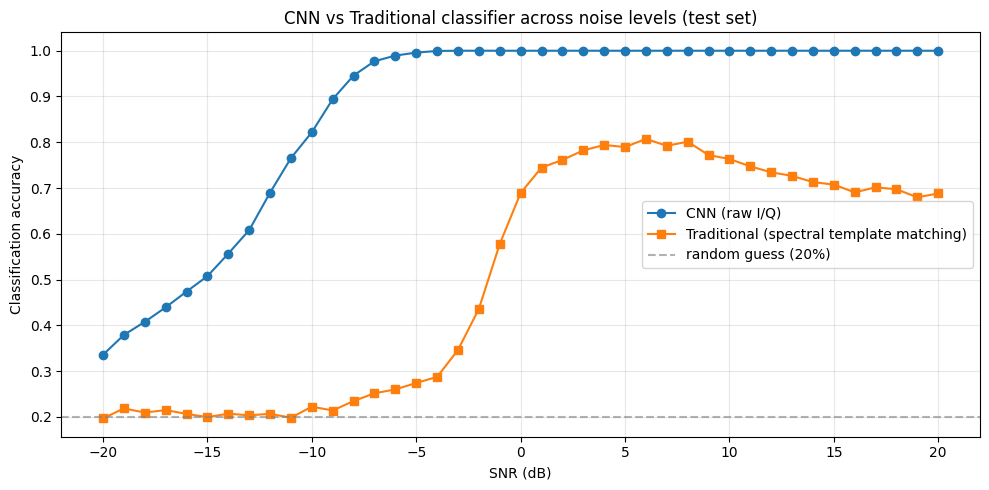

Plot saved to results/comparison_plot.png


In [7]:
# plot the comparison — both are 5-class classification accuracy on the same test set
plt.figure(figsize=(10, 5))
plt.plot(snr_levels, cnn_accs,  marker='o', label='CNN (raw I/Q)')
plt.plot(snr_levels, trad_accs, marker='s', label='Traditional (spectral template matching)')
plt.axhline(0.2, color='grey', linestyle='--', alpha=0.6, label='random guess (20%)')
plt.xlabel('SNR (dB)')
plt.ylabel('Classification accuracy')
plt.title('CNN vs Traditional classifier across noise levels (test set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/comparison_plot.png', dpi=150)
plt.show()
print('Plot saved to results/comparison_plot.png')